In [37]:
import os
import random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import tensorflow as tf


In [ ]:
# Path to the attached dataset
CSV_PATH = "/content/diabetes.csv"

# The dataset has no header row
data = pd.read_csv(CSV_PATH, header=None)

In [4]:
print("Dataset shape:", data.shape)
print("\nFirst five rows:")
data.head()

Dataset shape: (759, 9)

First five rows:


,0,1,2,3,4,5,6,7,8
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


In [5]:
print("\nColumn data types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nClass distribution:")
print(data.iloc[:, -1].value_counts())


Column data types:
0    float64
1    float64
2    float64
3    float64
4    float64
5    float64
6    float64
7    float64
8      int64
dtype: object

Missing values:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

Class distribution:
8
1    496
0    263
Name: count, dtype: int64


In [8]:
# Assign readable column names
feature_names = [f"Feature_{i}" for i in range(1, 9)]
data.columns = feature_names + ["Target"]

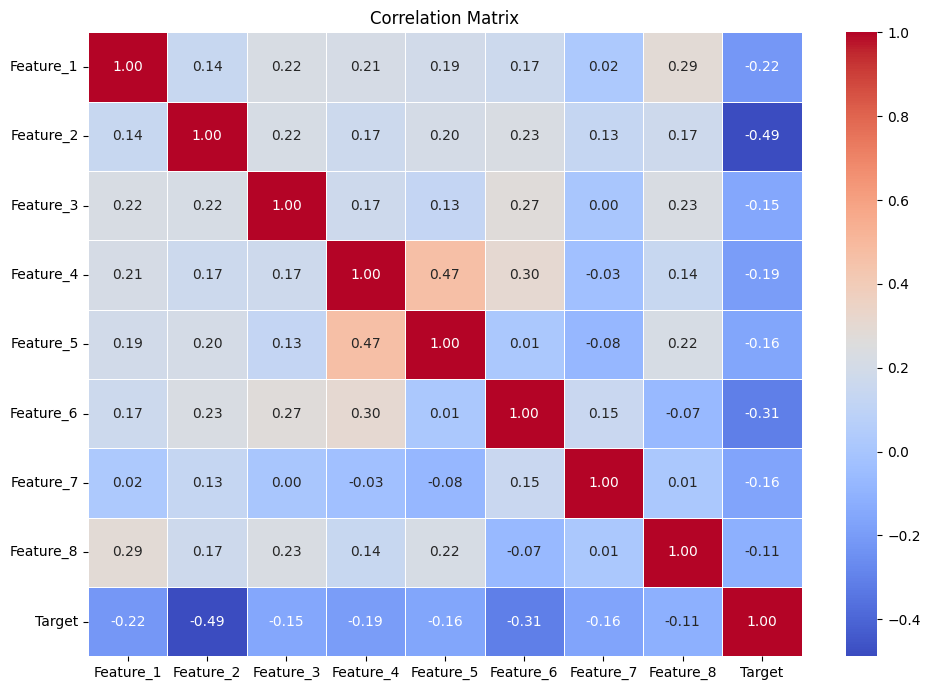

In [9]:
correlation = data.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

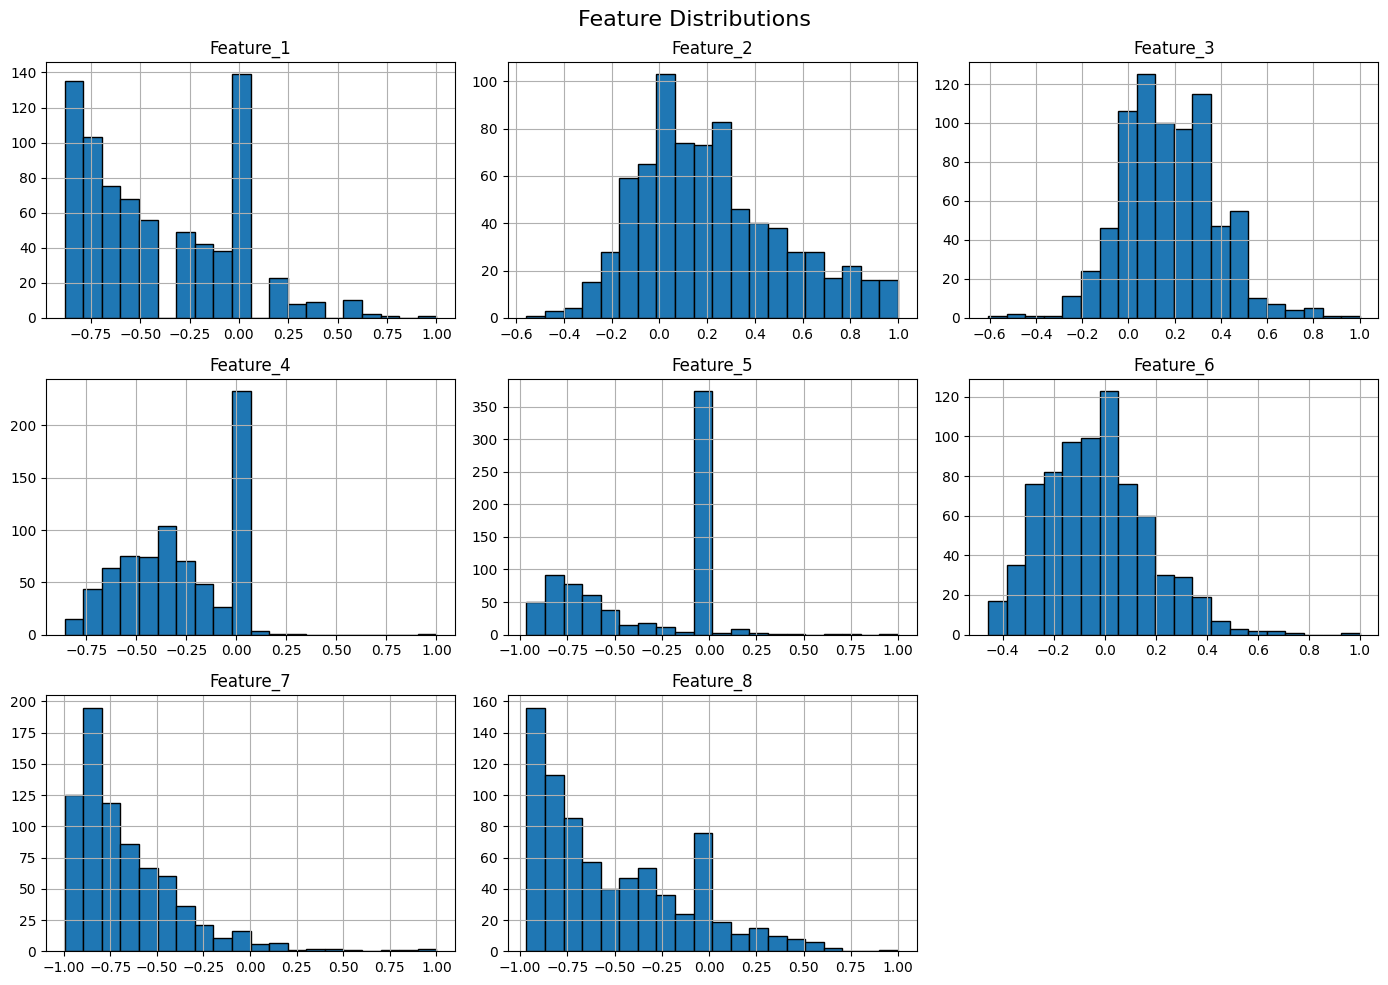

In [10]:
data[feature_names].hist(
    bins=20,
    figsize=(14, 10),
    edgecolor="black"
)

plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
SEED = 42

# Separate features and target
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Split temporary data into 15% validation and 15% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)


In [15]:
X_train.shape, X_temp.shape, y_train.shape, y_temp.shape

((531, 8), (228, 8), (531,), (228,))

In [16]:
X_val.shape, X_test.shape, y_val.shape, y_test.shape

((114, 8), (114, 8), (114,), (114,))

In [17]:
# Standardize using only the training data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

Training set: (531, 8)
Validation set: (114, 8)
Testing set: (114, 8)


In [18]:
# Baseline configuration
baseline_config = {
    "hidden_layers": [64, 32],
    "learning_rate": 0.001,
    "epochs": 30
}

# Modified configuration: HP_ID 2
HP_ID = 2

modified_config = {
    "hidden_layers": [64, 32],
    "learning_rate": 0.003,
    "epochs": 30
}

print("Baseline configuration:")
print(baseline_config)

print("\nModified configuration:")
print("HP_ID:", HP_ID)
print(modified_config)

Baseline configuration:
{'hidden_layers': [64, 32], 'learning_rate': 0.001, 'epochs': 30}

Modified configuration:
HP_ID: 2
{'hidden_layers': [64, 32], 'learning_rate': 0.003, 'epochs': 30}


### **Pytorch Code**

In [20]:
# Convert NumPy arrays into PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Create a training DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

print("PyTorch tensors created successfully.")
print("Training features shape:", X_train_tensor.shape)
print("Training labels shape:", y_train_tensor.shape)

PyTorch tensors created successfully.
Training features shape: torch.Size([531, 8])
Training labels shape: torch.Size([531, 1])


In [22]:
class DiabetesNetwork(nn.Module):
    def __init__(self, input_size, hidden_layers):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(previous_size, hidden_size))
            layers.append(nn.ReLU())
            previous_size = hidden_size

        # One output neuron for binary classification
        layers.append(nn.Linear(previous_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Create the baseline PyTorch model
baseline_model = DiabetesNetwork(
    input_size=X_train.shape[1],
    hidden_layers=baseline_config["hidden_layers"]
)

# Create the modified PyTorch model
modified_model = DiabetesNetwork(
    input_size=X_train.shape[1],
    hidden_layers=modified_config["hidden_layers"]
)

print("Baseline model:")
print(baseline_model)

print("\nModified model:")
print(modified_model)

Baseline model:
DiabetesNetwork(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Modified model:
DiabetesNetwork(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [24]:
# Use the same loss function for both frameworks
loss_function = nn.BCEWithLogitsLoss()

# Optimizer for the baseline model
baseline_optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=baseline_config["learning_rate"]
)

baseline_train_losses = []
baseline_validation_losses = []

for epoch in range(baseline_config["epochs"]):
    # Training mode
    baseline_model.train()
    total_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        baseline_optimizer.zero_grad()

        predictions = baseline_model(batch_X)
        loss = loss_function(predictions, batch_y)

        loss.backward()
        baseline_optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_train_loss / len(train_loader.dataset)

    # Validation mode
    baseline_model.eval()

    with torch.no_grad():
        validation_predictions = baseline_model(X_val_tensor)
        validation_loss = loss_function(
            validation_predictions,
            y_val_tensor
        ).item()

    baseline_train_losses.append(average_train_loss)
    baseline_validation_losses.append(validation_loss)

    print(
        f"Epoch [{epoch + 1}/{baseline_config['epochs']}], "
        f"Training Loss: {average_train_loss:.4f}, "
        f"Validation Loss: {validation_loss:.4f}"
    )

Epoch [1/30], Training Loss: 0.6406, Validation Loss: 0.6235
Epoch [2/30], Training Loss: 0.5898, Validation Loss: 0.5811
Epoch [3/30], Training Loss: 0.5428, Validation Loss: 0.5456
Epoch [4/30], Training Loss: 0.5022, Validation Loss: 0.5212
Epoch [5/30], Training Loss: 0.4771, Validation Loss: 0.5060
Epoch [6/30], Training Loss: 0.4632, Validation Loss: 0.4975
Epoch [7/30], Training Loss: 0.4573, Validation Loss: 0.4920
Epoch [8/30], Training Loss: 0.4491, Validation Loss: 0.4881
Epoch [9/30], Training Loss: 0.4471, Validation Loss: 0.4834
Epoch [10/30], Training Loss: 0.4453, Validation Loss: 0.4806
Epoch [11/30], Training Loss: 0.4391, Validation Loss: 0.4820
Epoch [12/30], Training Loss: 0.4373, Validation Loss: 0.4793
Epoch [13/30], Training Loss: 0.4353, Validation Loss: 0.4777
Epoch [14/30], Training Loss: 0.4310, Validation Loss: 0.4761
Epoch [15/30], Training Loss: 0.4291, Validation Loss: 0.4757
Epoch [16/30], Training Loss: 0.4259, Validation Loss: 0.4763
Epoch [17/30], Tr

In [25]:
# Optimizer for the modified model
modified_optimizer = optim.Adam(
    modified_model.parameters(),
    lr=modified_config["learning_rate"]
)

modified_train_losses = []
modified_validation_losses = []

for epoch in range(modified_config["epochs"]):
    # Training mode
    modified_model.train()
    total_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        modified_optimizer.zero_grad()

        predictions = modified_model(batch_X)
        loss = loss_function(predictions, batch_y)

        loss.backward()
        modified_optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_train_loss / len(train_loader.dataset)

    # Validation mode
    modified_model.eval()

    with torch.no_grad():
        validation_predictions = modified_model(X_val_tensor)
        validation_loss = loss_function(
            validation_predictions,
            y_val_tensor
        ).item()

    modified_train_losses.append(average_train_loss)
    modified_validation_losses.append(validation_loss)

    print(
        f"Epoch [{epoch + 1}/{modified_config['epochs']}], "
        f"Training Loss: {average_train_loss:.4f}, "
        f"Validation Loss: {validation_loss:.4f}"
    )

Epoch [1/30], Training Loss: 0.6036, Validation Loss: 0.5452
Epoch [2/30], Training Loss: 0.4949, Validation Loss: 0.4924
Epoch [3/30], Training Loss: 0.4660, Validation Loss: 0.4777
Epoch [4/30], Training Loss: 0.4467, Validation Loss: 0.4691
Epoch [5/30], Training Loss: 0.4393, Validation Loss: 0.4676
Epoch [6/30], Training Loss: 0.4324, Validation Loss: 0.4687
Epoch [7/30], Training Loss: 0.4316, Validation Loss: 0.4681
Epoch [8/30], Training Loss: 0.4239, Validation Loss: 0.4695
Epoch [9/30], Training Loss: 0.4185, Validation Loss: 0.4652
Epoch [10/30], Training Loss: 0.4146, Validation Loss: 0.4664
Epoch [11/30], Training Loss: 0.4101, Validation Loss: 0.4676
Epoch [12/30], Training Loss: 0.4010, Validation Loss: 0.4665
Epoch [13/30], Training Loss: 0.3983, Validation Loss: 0.4644
Epoch [14/30], Training Loss: 0.3973, Validation Loss: 0.4606
Epoch [15/30], Training Loss: 0.3885, Validation Loss: 0.4667
Epoch [16/30], Training Loss: 0.3860, Validation Loss: 0.4643
Epoch [17/30], Tr

In [26]:
# Optimizer for the modified model
modified_optimizer = optim.Adam(
    modified_model.parameters(),
    lr=modified_config["learning_rate"]
)

modified_train_losses = []
modified_validation_losses = []

for epoch in range(modified_config["epochs"]):
    # Training mode
    modified_model.train()
    total_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        modified_optimizer.zero_grad()

        predictions = modified_model(batch_X)
        loss = loss_function(predictions, batch_y)

        loss.backward()
        modified_optimizer.step()

        total_train_loss += loss.item() * batch_X.size(0)

    average_train_loss = total_train_loss / len(train_loader.dataset)

    # Validation mode
    modified_model.eval()

    with torch.no_grad():
        validation_predictions = modified_model(X_val_tensor)
        validation_loss = loss_function(
            validation_predictions,
            y_val_tensor
        ).item()

    modified_train_losses.append(average_train_loss)
    modified_validation_losses.append(validation_loss)

    print(
        f"Epoch [{epoch + 1}/{modified_config['epochs']}], "
        f"Training Loss: {average_train_loss:.4f}, "
        f"Validation Loss: {validation_loss:.4f}"
    )

Epoch [1/30], Training Loss: 0.3220, Validation Loss: 0.4864
Epoch [2/30], Training Loss: 0.3035, Validation Loss: 0.5125
Epoch [3/30], Training Loss: 0.2997, Validation Loss: 0.5009
Epoch [4/30], Training Loss: 0.2948, Validation Loss: 0.4995
Epoch [5/30], Training Loss: 0.2859, Validation Loss: 0.5247
Epoch [6/30], Training Loss: 0.2862, Validation Loss: 0.5097
Epoch [7/30], Training Loss: 0.2778, Validation Loss: 0.5182
Epoch [8/30], Training Loss: 0.2717, Validation Loss: 0.5401
Epoch [9/30], Training Loss: 0.2630, Validation Loss: 0.5269
Epoch [10/30], Training Loss: 0.2590, Validation Loss: 0.5296
Epoch [11/30], Training Loss: 0.2659, Validation Loss: 0.5385
Epoch [12/30], Training Loss: 0.2576, Validation Loss: 0.5547
Epoch [13/30], Training Loss: 0.2500, Validation Loss: 0.5536
Epoch [14/30], Training Loss: 0.2504, Validation Loss: 0.5979
Epoch [15/30], Training Loss: 0.2417, Validation Loss: 0.5590
Epoch [16/30], Training Loss: 0.2287, Validation Loss: 0.5703
Epoch [17/30], Tr

In [27]:
def calculate_accuracy(model, X_data, y_data):
    model.eval()

    with torch.no_grad():
        logits = model(X_data)

        # Convert logits into probabilities
        probabilities = torch.sigmoid(logits)

        # Convert probabilities into class predictions
        predictions = (probabilities >= 0.5).float()

        correct_predictions = (predictions == y_data).sum().item()
        total_predictions = y_data.size(0)

    return correct_predictions / total_predictions


baseline_test_accuracy = calculate_accuracy(
    baseline_model,
    X_test_tensor,
    y_test_tensor
)

modified_test_accuracy = calculate_accuracy(
    modified_model,
    X_test_tensor,
    y_test_tensor
)

print(f"Baseline PyTorch test accuracy: "
      f"{baseline_test_accuracy:.4f}")

print(f"Modified PyTorch test accuracy: "
      f"{modified_test_accuracy:.4f}")

Baseline PyTorch test accuracy: 0.7807
Modified PyTorch test accuracy: 0.7281


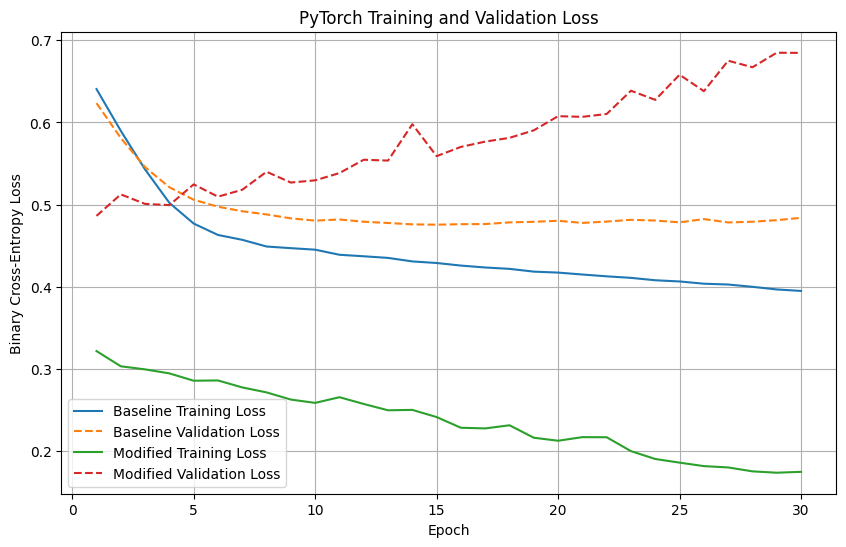

In [28]:
epochs = range(1, len(baseline_train_losses) + 1)

plt.figure(figsize=(10, 6))

# Baseline losses
plt.plot(
    epochs,
    baseline_train_losses,
    label="Baseline Training Loss",
    linestyle="-"
)

plt.plot(
    epochs,
    baseline_validation_losses,
    label="Baseline Validation Loss",
    linestyle="--"
)

# Modified losses
plt.plot(
    epochs,
    modified_train_losses,
    label="Modified Training Loss",
    linestyle="-"
)

plt.plot(
    epochs,
    modified_validation_losses,
    label="Modified Validation Loss",
    linestyle="--"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("PyTorch Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### **TensorFlow Code**

In [29]:
# Set the TensorFlow random seed
tf.random.set_seed(SEED)

# Convert the data to TensorFlow tensors
X_train_tf = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train, dtype=tf.float32)

X_val_tf = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_val_tf = tf.convert_to_tensor(y_val, dtype=tf.float32)

X_test_tf = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test, dtype=tf.float32)

# Create a TensorFlow training dataset
train_dataset_tf = tf.data.Dataset.from_tensor_slices(
    (X_train_tf, y_train_tf)
)

train_dataset_tf = train_dataset_tf.shuffle(
    buffer_size=len(X_train),
    seed=SEED,
    reshuffle_each_iteration=True
).batch(32)

print("TensorFlow data prepared successfully.")
print("Training features shape:", X_train_tf.shape)
print("Training labels shape:", y_train_tf.shape)

TensorFlow data prepared successfully.
Training features shape: (531, 8)
Training labels shape: (531,)


In [30]:
def create_tensorflow_model(hidden_layers):
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

    # Hidden layers
    for neurons in hidden_layers:
        model.add(
            tf.keras.layers.Dense(
                neurons,
                activation="relu"
            )
        )

    # Output layer for binary classification
    model.add(tf.keras.layers.Dense(1))

    return model


# Create the TensorFlow baseline model
baseline_tf_model = create_tensorflow_model(
    baseline_config["hidden_layers"]
)

# Create the TensorFlow modified model
modified_tf_model = create_tensorflow_model(
    modified_config["hidden_layers"]
)

print("TensorFlow baseline model:")
baseline_tf_model.summary()

print("\nTensorFlow modified model:")
modified_tf_model.summary()

TensorFlow baseline model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compile the baseline TensorFlow model
baseline_tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=baseline_config["learning_rate"]
    ),
    loss=tf.keras.losses.BinaryCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

# Compile the modified TensorFlow model
modified_tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=modified_config["learning_rate"]
    ),
    loss=tf.keras.losses.BinaryCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

print("Both TensorFlow models compiled successfully.")

Both TensorFlow models compiled successfully.


In [32]:
baseline_tf_history = baseline_tf_model.fit(
    X_train_tf,
    y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=baseline_config["epochs"],
    batch_size=32,
    verbose=1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - accuracy: 0.5706 - loss: 0.6098 - val_accuracy: 0.6579 - val_loss: 0.5676
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6987 - loss: 0.5301 - val_accuracy: 0.7193 - val_loss: 0.5184
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7458 - loss: 0.4866 - val_accuracy: 0.7456 - val_loss: 0.4921
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7702 - loss: 0.4647 - val_accuracy: 0.7281 - val_loss: 0.4781
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7702 - loss: 0.4536 - val_accuracy: 0.7281 - val_loss: 0.4708
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7797 - loss: 0.4469 - val_accuracy: 0.7281 - val_loss: 0.4666
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7797 - loss: 0.4423 - val_accuracy: 0.7281 - val_loss: 0.4642
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7853 - loss: 0.4382 - val_accuracy: 0.7281 - val_los

In [34]:
modified_tf_history = modified_tf_model.fit(
    X_train_tf,
    y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=modified_config["epochs"],
    batch_size=32,
    verbose=1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.5537 - loss: 0.6321 - val_accuracy: 0.7456 - val_loss: 0.5155
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7533 - loss: 0.4766 - val_accuracy: 0.7456 - val_loss: 0.4839
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7778 - loss: 0.4497 - val_accuracy: 0.7456 - val_loss: 0.4694
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7797 - loss: 0.4381 - val_accuracy: 0.7456 - val_loss: 0.4645
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7891 - loss: 0.4296 - val_accuracy: 0.7456 - val_loss: 0.4631
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7891 - loss: 0.4223 - val_accuracy: 0.7456 - val_loss: 0.4612
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7966 - loss: 0.4153 - val_accuracy: 0.7456 - val_loss: 0.4602
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8004 - loss: 0.4089 - val_accuracy: 0.7544 - val_lo

In [35]:
# Evaluate the baseline model
baseline_tf_results = baseline_tf_model.evaluate(
    X_test_tf,
    y_test_tf,
    verbose=0
)

# Evaluate the modified model
modified_tf_results = modified_tf_model.evaluate(
    X_test_tf,
    y_test_tf,
    verbose=0
)

# The second value is accuracy because metrics=["accuracy"]
baseline_tf_test_accuracy = baseline_tf_results[1]
modified_tf_test_accuracy = modified_tf_results[1]

print(f"Baseline TensorFlow test accuracy: "
      f"{baseline_tf_test_accuracy:.4f}")

print(f"Modified TensorFlow test accuracy: "
      f"{modified_tf_test_accuracy:.4f}")

Baseline TensorFlow test accuracy: 0.7544
Modified TensorFlow test accuracy: 0.7632


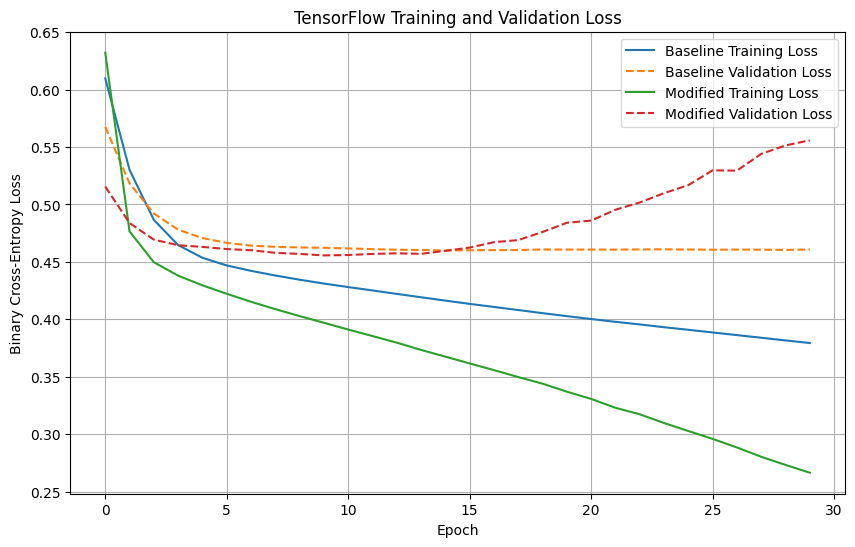

In [36]:
plt.figure(figsize=(10, 6))

# Baseline TensorFlow losses
plt.plot(
    baseline_tf_history.history["loss"],
    label="Baseline Training Loss"
)

plt.plot(
    baseline_tf_history.history["val_loss"],
    label="Baseline Validation Loss",
    linestyle="--"
)

# Modified TensorFlow losses
plt.plot(
    modified_tf_history.history["loss"],
    label="Modified Training Loss"
)

plt.plot(
    modified_tf_history.history["val_loss"],
    label="Modified Validation Loss",
    linestyle="--"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("TensorFlow Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)


def run_pytorch_model(config, seed):
    set_seed(seed)

    model = DiabetesNetwork(
        input_size=X_train.shape[1],
        hidden_layers=config["hidden_layers"]
    )

    optimizer = optim.Adam(
        model.parameters(),
        lr=config["learning_rate"]
    )

    for epoch in range(config["epochs"]):
        model.train()

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            predictions = model(batch_X)
            loss = loss_function(predictions, batch_y)

            loss.backward()
            optimizer.step()

    return calculate_accuracy(
        model,
        X_test_tensor,
        y_test_tensor
    )


training_seeds = [SEED, SEED + 1, SEED + 2]

baseline_pytorch_accuracies = []
modified_pytorch_accuracies = []

for seed in training_seeds:
    baseline_accuracy = run_pytorch_model(
        baseline_config,
        seed
    )

    modified_accuracy = run_pytorch_model(
        modified_config,
        seed
    )

    baseline_pytorch_accuracies.append(baseline_accuracy)
    modified_pytorch_accuracies.append(modified_accuracy)

print("Baseline PyTorch accuracies:")
print(baseline_pytorch_accuracies)

print("Modified PyTorch accuracies:")
print(modified_pytorch_accuracies)

print("\nBaseline PyTorch mean:",
      np.mean(baseline_pytorch_accuracies))

print("Baseline PyTorch standard deviation:",
      np.std(baseline_pytorch_accuracies, ddof=1))

print("\nModified PyTorch mean:",
      np.mean(modified_pytorch_accuracies))

print("Modified PyTorch standard deviation:",
      np.std(modified_pytorch_accuracies, ddof=1))

Baseline PyTorch accuracies:
[0.7894736842105263, 0.7631578947368421, 0.7631578947368421]
Modified PyTorch accuracies:
[0.7368421052631579, 0.7631578947368421, 0.7807017543859649]

Baseline PyTorch mean: 0.7719298245614036
Baseline PyTorch standard deviation: 0.015193428136569083

Modified PyTorch mean: 0.7602339181286549
Modified PyTorch standard deviation: 0.022075539284417415


In [39]:
def run_tensorflow_model(config, seed):
    # Set the TensorFlow seed
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    model = create_tensorflow_model(
        config["hidden_layers"]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        ),
        loss=tf.keras.losses.BinaryCrossentropy(
            from_logits=True
        ),
        metrics=["accuracy"]
    )

    model.fit(
        X_train_tf,
        y_train_tf,
        validation_data=(X_val_tf, y_val_tf),
        epochs=config["epochs"],
        batch_size=32,
        verbose=0,
        shuffle=True
    )

    results = model.evaluate(
        X_test_tf,
        y_test_tf,
        verbose=0
    )

    return results[1]


baseline_tensorflow_accuracies = []
modified_tensorflow_accuracies = []

for seed in training_seeds:
    baseline_accuracy = run_tensorflow_model(
        baseline_config,
        seed
    )

    modified_accuracy = run_tensorflow_model(
        modified_config,
        seed
    )

    baseline_tensorflow_accuracies.append(baseline_accuracy)
    modified_tensorflow_accuracies.append(modified_accuracy)

print("Baseline TensorFlow accuracies:")
print(baseline_tensorflow_accuracies)

print("Modified TensorFlow accuracies:")
print(modified_tensorflow_accuracies)

print("\nBaseline TensorFlow mean:",
      np.mean(baseline_tensorflow_accuracies))

print("Baseline TensorFlow standard deviation:",
      np.std(baseline_tensorflow_accuracies, ddof=1))

print("\nModified TensorFlow mean:",
      np.mean(modified_tensorflow_accuracies))

print("Modified TensorFlow standard deviation:",
      np.std(modified_tensorflow_accuracies, ddof=1))

Baseline TensorFlow accuracies:
[0.7894737124443054, 0.7894737124443054, 0.7719298005104065]
Modified TensorFlow accuracies:
[0.7719298005104065, 0.7719298005104065, 0.780701756477356]

Baseline TensorFlow mean: 0.7836257417996725
Baseline TensorFlow standard deviation: 0.010128982277675632

Modified TensorFlow mean: 0.774853785832723
Modified TensorFlow standard deviation: 0.005064491138837816


In [40]:
results_table = pd.DataFrame({
    "Framework": [
        "PyTorch",
        "PyTorch",
        "TensorFlow",
        "TensorFlow"
    ],
    "Model": [
        "Baseline",
        "Modified HP_ID 2",
        "Baseline",
        "Modified HP_ID 2"
    ],
    "Mean Test Accuracy": [
        np.mean(baseline_pytorch_accuracies),
        np.mean(modified_pytorch_accuracies),
        np.mean(baseline_tensorflow_accuracies),
        np.mean(modified_tensorflow_accuracies)
    ],
    "Standard Deviation": [
        np.std(baseline_pytorch_accuracies, ddof=1),
        np.std(modified_pytorch_accuracies, ddof=1),
        np.std(baseline_tensorflow_accuracies, ddof=1),
        np.std(modified_tensorflow_accuracies, ddof=1)
    ]
})

# Display percentages instead of decimal values
results_table["Mean Test Accuracy"] *= 100
results_table["Standard Deviation"] *= 100

print(results_table.to_string(index=False))

 Framework            Model  Mean Test Accuracy  Standard Deviation
   PyTorch         Baseline           77.192982            1.519343
   PyTorch Modified HP_ID 2           76.023392            2.207554
TensorFlow         Baseline           78.362574            1.012898
TensorFlow Modified HP_ID 2           77.485379            0.506449
